# 🐔 Poultry Health CNN V2 — Fixed (Kaggle)

### Setup:
1. **Enable GPU**: Settings → Accelerator → GPU T4 x2
2. **Add Dataset**: Already added
3. **Run All**

In [1]:
# ============================================================
# CELL 1: GPU Check
# ============================================================
import tensorflow as tf
print("=" * 70)
print("GPU CHECK")
print("=" * 70)
print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU Available: {gpus}")
if gpus:
    print("✓ GPU is ready!")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠ No GPU. Go to Settings → Accelerator → GPU T4 x2")
print("=" * 70)

2026-04-13 21:09:02.551495: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776114542.741427      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776114542.797067      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776114543.262638      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776114543.262678      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776114543.262681      23 computation_placer.cc:177] computation placer alr

GPU CHECK
TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✓ GPU is ready!


In [2]:
# ============================================================
# CELL 2: Install & Import
# ============================================================
!pip install -q librosa soundfile scikit-learn tqdm imbalanced-learn

import numpy as np
import librosa
import os
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle

from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
OUTPUT_DIR = '/kaggle/working/'
print("✓ All libraries imported!")

✓ All libraries imported!


In [3]:
# ============================================================
# CELL 3: Feature Extraction (with value clipping)
# ============================================================

def extract_features_v2(signal, sr=96000):
    """Extract features with safe value ranges."""
    features = {}
    if len(signal) < 2048:
        signal = np.pad(signal, (0, 2048 - len(signal)), mode='constant')

    # MFCC (80)
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40, n_fft=2048, hop_length=512)
    for i in range(40):
        features[f'mfcc_{i}_mean'] = np.mean(mfcc[i])
        features[f'mfcc_{i}_std'] = np.std(mfcc[i])

    # Delta MFCC (80)
    delta_mfcc = librosa.feature.delta(mfcc)
    for i in range(40):
        features[f'delta_mfcc_{i}_mean'] = np.mean(delta_mfcc[i])
        features[f'delta_mfcc_{i}_std'] = np.std(delta_mfcc[i])

    # Chroma (24)
    chroma = librosa.feature.chroma_stft(y=signal, sr=sr, n_fft=2048, hop_length=512)
    for i in range(12):
        features[f'chroma_{i}_mean'] = np.mean(chroma[i])
        features[f'chroma_{i}_std'] = np.std(chroma[i])

    # Mel Spectrogram Stats (7)
    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    features['mel_spec_mean'] = np.mean(mel_spec_db)
    features['mel_spec_std'] = np.std(mel_spec_db)
    features['mel_spec_max'] = np.max(mel_spec_db)
    features['mel_spec_min'] = np.min(mel_spec_db)
    n_bands = mel_spec.shape[0]
    features['mel_low_energy'] = np.mean(mel_spec_db[:n_bands//3, :])
    features['mel_mid_energy'] = np.mean(mel_spec_db[n_bands//3:2*n_bands//3, :])
    features['mel_high_energy'] = np.mean(mel_spec_db[2*n_bands//3:, :])

    # Spectral Contrast (14)
    try:
        contrast = librosa.feature.spectral_contrast(y=signal, sr=sr, n_fft=2048, hop_length=512)
        for i in range(min(7, contrast.shape[0])):
            features[f'contrast_{i}_mean'] = np.mean(contrast[i])
            features[f'contrast_{i}_std'] = np.std(contrast[i])
    except Exception:
        for i in range(7):
            features[f'contrast_{i}_mean'] = 0.0
            features[f'contrast_{i}_std'] = 0.0

    # Tonnetz (12)
    try:
        harmonic = librosa.effects.harmonic(signal)
        tonnetz = librosa.feature.tonnetz(y=harmonic, sr=sr)
        for i in range(6):
            features[f'tonnetz_{i}_mean'] = np.mean(tonnetz[i])
            features[f'tonnetz_{i}_std'] = np.std(tonnetz[i])
    except Exception:
        for i in range(6):
            features[f'tonnetz_{i}_mean'] = 0.0
            features[f'tonnetz_{i}_std'] = 0.0

    # Spectral features (8)
    spectral_centroid = librosa.feature.spectral_centroid(y=signal, sr=sr)[0]
    spectral_rolloff = librosa.feature.spectral_rolloff(y=signal, sr=sr)[0]
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=signal, sr=sr)[0]
    zcr = librosa.feature.zero_crossing_rate(signal)[0]
    features['spectral_centroid_mean'] = np.mean(spectral_centroid)
    features['spectral_centroid_std'] = np.std(spectral_centroid)
    features['spectral_rolloff_mean'] = np.mean(spectral_rolloff)
    features['spectral_rolloff_std'] = np.std(spectral_rolloff)
    features['spectral_bandwidth_mean'] = np.mean(spectral_bandwidth)
    features['spectral_bandwidth_std'] = np.std(spectral_bandwidth)
    features['zero_crossing_rate_mean'] = np.mean(zcr)
    features['zero_crossing_rate_std'] = np.std(zcr)

    # Spectral Flatness (2)
    spec_flat = librosa.feature.spectral_flatness(y=signal)[0]
    features['spectral_flatness_mean'] = np.mean(spec_flat)
    features['spectral_flatness_std'] = np.std(spec_flat)

    # Spectral Entropy (1)
    power = np.abs(np.fft.fft(signal)) ** 2
    power = power[:len(power)//2]
    power_sum = np.sum(power)
    if power_sum > 0:
        power_norm = power / power_sum
        features['spectral_entropy'] = -np.sum(power_norm * np.log2(power_norm + 1e-12))
    else:
        features['spectral_entropy'] = 0.0

    # Autocorrelation (3)
    autocorr = librosa.autocorrelate(signal, max_size=min(5000, len(signal)//2))
    if len(autocorr) > 1:
        autocorr_norm = autocorr / (autocorr[0] + 1e-10)
        end = min(100, len(autocorr_norm))
        features['autocorr_max'] = np.max(autocorr_norm[1:end])
        features['autocorr_mean'] = np.mean(autocorr_norm[1:end])
        features['autocorr_std'] = np.std(autocorr_norm[1:end])
    else:
        features['autocorr_max'] = 0.0
        features['autocorr_mean'] = 0.0
        features['autocorr_std'] = 0.0

    # Statistical features (8)
    features['sig_mean'] = np.mean(signal)
    features['sig_std'] = np.std(signal)
    features['sig_var'] = np.var(signal)
    features['sig_max'] = np.max(signal)
    features['sig_min'] = np.min(signal)
    features['sig_rms'] = np.sqrt(np.mean(signal**2))
    sig_std_safe = np.std(signal) + 1e-10
    features['sig_skewness'] = np.mean(((signal - np.mean(signal)) / sig_std_safe) ** 3)
    features['sig_kurtosis'] = np.mean(((signal - np.mean(signal)) / sig_std_safe) ** 4)

    # RMS Energy Stats (4)
    rms_frames = librosa.feature.rms(y=signal, frame_length=2048, hop_length=512)[0]
    features['rms_mean'] = np.mean(rms_frames)
    features['rms_std'] = np.std(rms_frames)
    features['rms_max'] = np.max(rms_frames)
    features['rms_min'] = np.min(rms_frames)

    # CLIP extreme values
    feat_array = np.array(list(features.values()), dtype=np.float32)
    feat_array = np.clip(feat_array, -1e6, 1e6)
    feat_array = np.nan_to_num(feat_array, nan=0.0, posinf=1e6, neginf=-1e6)
    return feat_array

_test = np.random.randn(96000).astype(np.float32)
_feat = extract_features_v2(_test, sr=96000)
NUM_FEATURES = len(_feat)
print(f"✓ Feature extraction defined! Total features: {NUM_FEATURES}")
del _test, _feat

✓ Feature extraction defined! Total features: 243


In [4]:
# ============================================================
# CELL 4: Data Augmentation (REDUCED to 3)
# ============================================================

def augment_audio(audio, sr=96000):
    """Generate 3 augmented versions (reduced from 7)."""
    augmented = []
    
    # 1. Adding Gaussian noise
    noise = np.random.normal(0, 0.005, len(audio))
    augmented.append((audio + noise, 'gaussian_noise'))
    
    # 2. Pitch Shifting (+2 semitones)
    try:
        pitched = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)
        augmented.append((pitched, 'pitch_up'))
    except Exception:
        pass
    
    # 3. Volume scaling (louder)
    augmented.append((audio * 1.3, 'volume_up'))
    
    return augmented

print("✓ Augmentation defined (3 per sample: noise, pitch, volume)")

✓ Augmentation defined (3 per sample: noise, pitch, volume)


In [5]:
# ============================================================
# CELL 5: Verify Dataset Paths (KAGGLE)
# ============================================================
# ⚠️ IMPORTANT: UPDATE THE DATASET NAME BELOW!
#
# Option A: If you uploaded as a Kaggle Dataset:
#   Go to sidebar → 'Add data' → search your dataset → Add
#   Then expand it in sidebar to see the exact folder paths.
#   Replace 'poultry-audio-dataset' below with your dataset name.
#
# Option B: If you uploaded a ZIP with all 3 folders:
#   The path will be: /kaggle/input/YOUR_DATASET_NAME/
#
# ============================================================

# =====> CHANGE THIS TO YOUR DATASET NAME <=====
DATASET_NAME = 'dataset-chicken-audio'
# ===============================================

base_path = '/kaggle/input/datasets/sohelakhtar1/dataset-chicken-audio/Poultry Vocalization Signal Dataset for Early Disease\xa0Detection/Chicken_Audio_Dataset/'


# Try to auto-detect dataset path
if not os.path.exists(base_path):
    print(f"⚠ Path not found: {base_path}")
    print("\nSearching /kaggle/input/ for your dataset...")
    input_path = '/kaggle/input/'
    if os.path.exists(input_path):
        for item in os.listdir(input_path):
            full_path = os.path.join(input_path, item)
            if os.path.isdir(full_path):
                print(f"  Found: {full_path}/")
                sub_items = os.listdir(full_path)
                print(f"    Contents: {sub_items[:10]}")
                # Check if Healthy folder exists directly or one level deeper
                if 'Healthy' in sub_items:
                    base_path = full_path + '/'
                    print(f"  ✓ Auto-detected dataset path: {base_path}")
                    break
                else:
                    # Check one level deeper
                    for sub in sub_items:
                        deeper = os.path.join(full_path, sub)
                        if os.path.isdir(deeper):
                            deeper_items = os.listdir(deeper)
                            if 'Healthy' in deeper_items:
                                base_path = deeper + '/'
                                print(f"  ✓ Auto-detected dataset path: {base_path}")
                                break

# FALLBACK: os.walk deep search if still not found
if not os.path.exists(base_path + 'Healthy'):
    print("\nDeep searching with os.walk...")
    for dirpath, dirnames, filenames in os.walk('/kaggle/input'):
        if 'Healthy' in dirnames and 'Noise' in dirnames and 'Unhealthy' in dirnames:
            base_path = dirpath + '/'
            print(f"  ✓ Found dataset at: {base_path}")
            break

# Define paths
healthy_dir = base_path + 'Healthy'
noise_dir = base_path + 'Noise'
unhealthy_dir = base_path + 'Unhealthy'

# Verify
print(f"\n{'='*70}")
print("DATASET PATH VERIFICATION")
print(f"{'='*70}")
for name, path in [('Healthy', healthy_dir), ('Noise', noise_dir), ('Unhealthy', unhealthy_dir)]:
    exists = os.path.exists(path)
    count = len(list(Path(path).glob('*.wav'))) if exists else 0
    status = f"✓ {count} files" if exists else "✗ NOT FOUND"
    print(f"  {name:12s}: {path} → {status}")

if not all(os.path.exists(p) for p in [healthy_dir, noise_dir, unhealthy_dir]):
    print("\n❌ ERROR: Some folders not found!")
    print("   Fix: Update DATASET_NAME variable at top of this cell.")
    print("   Or check sidebar → /kaggle/input/ for the correct path.")
else:
    print("\n✓ All dataset folders found!")
print(f"{'='*70}")


DATASET PATH VERIFICATION
  Healthy     : /kaggle/input/datasets/sohelakhtar1/dataset-chicken-audio/Poultry Vocalization Signal Dataset for Early Disease Detection/Chicken_Audio_Dataset/Healthy → ✓ 139 files
  Noise       : /kaggle/input/datasets/sohelakhtar1/dataset-chicken-audio/Poultry Vocalization Signal Dataset for Early Disease Detection/Chicken_Audio_Dataset/Noise → ✓ 86 files
  Unhealthy   : /kaggle/input/datasets/sohelakhtar1/dataset-chicken-audio/Poultry Vocalization Signal Dataset for Early Disease Detection/Chicken_Audio_Dataset/Unhealthy → ✓ 121 files

✓ All dataset folders found!


In [6]:
# ============================================================
# CELL 6: Load ALL Dataset Files + Augmentation
# ============================================================
print("=" * 70)
print("LOADING DATASET (ALL FILES + AUGMENTATION)")
print("=" * 70)

class_names = ['Healthy', 'Noise', 'Unhealthy']
class_to_idx = {'Healthy': 0, 'Noise': 1, 'Unhealthy': 2}

X_data = []
y_data = []
augmentation_log = {'original': 0, 'augmented': 0}

def process_directory(dir_path, label, class_name, augment=True):
    """Process all .wav files in a directory with optional augmentation."""
    files = sorted(Path(dir_path).glob('*.wav'))
    processed = 0
    aug_count = 0
    
    print(f"\nProcessing {class_name} files ({len(files)} found)...")
    
    for file in tqdm(files, desc=class_name):
        try:
            # Original audio
            audio, sr = librosa.load(str(file), sr=96000, mono=True, duration=10)
            
            # Pad short audio
            min_length = sr * 2
            if len(audio) < min_length:
                audio = np.pad(audio, (0, min_length - len(audio)), mode='constant')
            
            # Apply preprocessing
            N = len(audio)
            n = np.arange(N)
            hamming_window = 0.54 + 0.46 * np.cos((2 * np.pi / N) * n)
            windowed = audio * hamming_window
            
            alpha = 0.3
            filtered = np.zeros_like(windowed)
            filtered[0] = windowed[0]
            for i in range(1, len(windowed)):
                filtered[i] = alpha * windowed[i] + (1 - alpha) * filtered[i-1]
            
            # Extract features from original
            features = extract_features_v2(filtered, sr)
            X_data.append(features)
            y_data.append(label)
            processed += 1
            augmentation_log['original'] += 1
            
            # Augmentation
            if augment:
                aug_signals = augment_audio(audio, sr)
                for aug_signal, aug_name in aug_signals:
                    try:
                        N_aug = len(aug_signal)
                        n_aug = np.arange(N_aug)
                        ham_aug = 0.54 + 0.46 * np.cos((2 * np.pi / N_aug) * n_aug)
                        win_aug = aug_signal * ham_aug
                        
                        filt_aug = np.zeros_like(win_aug)
                        filt_aug[0] = win_aug[0]
                        for i in range(1, len(win_aug)):
                            filt_aug[i] = alpha * win_aug[i] + (1 - alpha) * filt_aug[i-1]
                        
                        aug_features = extract_features_v2(filt_aug, sr)
                        X_data.append(aug_features)
                        y_data.append(label)
                        aug_count += 1
                        augmentation_log['augmented'] += 1
                    except Exception:
                        pass
        
        except Exception as e:
            print(f"  ✗ Error processing {file.name}: {e}")
    
    print(f"  ✓ {class_name}: {processed} originals + {aug_count} augmented = {processed + aug_count} total")


# Process ALL files (NO caps)
process_directory(healthy_dir, 0, 'Healthy', augment=True)
process_directory(noise_dir, 1, 'Noise', augment=True)
process_directory(unhealthy_dir, 2, 'Unhealthy', augment=True)

# Convert to numpy arrays
X_data = np.array(X_data)
y_data = np.array(y_data)

# CRITICAL: Clip and clean ALL features
X_data = np.clip(X_data, -1e6, 1e6)
X_data = np.nan_to_num(X_data, nan=0.0, posinf=0.0, neginf=0.0)

print("\n" + "=" * 70)
print("DATASET LOADED")
print("=" * 70)
print(f"Total samples: {len(X_data)}")
print(f"Feature shape: {X_data.shape}")
print(f"Original: {augmentation_log['original']}, Augmented: {augmentation_log['augmented']}")
print(f"\nClass distribution:")
unique, counts = np.unique(y_data, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  {class_names[cls]:12s}: {count:4d} samples ({count/len(y_data)*100:.1f}%)")
print(f"Feature value range: [{X_data.min():.2f}, {X_data.max():.2f}]")
print("=" * 70)

LOADING DATASET (ALL FILES + AUGMENTATION)

Processing Healthy files (139 found)...


Healthy: 100%|██████████| 139/139 [42:23<00:00, 18.30s/it]


  ✓ Healthy: 139 originals + 417 augmented = 556 total

Processing Noise files (86 found)...


Noise: 100%|██████████| 86/86 [23:56<00:00, 16.71s/it]


  ✓ Noise: 86 originals + 258 augmented = 344 total

Processing Unhealthy files (121 found)...


Unhealthy: 100%|██████████| 121/121 [29:20<00:00, 14.55s/it]

  ✓ Unhealthy: 121 originals + 363 augmented = 484 total

DATASET LOADED
Total samples: 1384
Feature shape: (1384, 243)
Original: 346, Augmented: 1038

Class distribution:
  Healthy     :  556 samples (40.2%)
  Noise       :  344 samples (24.9%)
  Unhealthy   :  484 samples (35.0%)
Feature value range: [-724.34, 30741.90]


In [7]:
# ============================================================
# CELL 7: Prepare Data — Split, Scale, SMOTE, Encode
# ============================================================
print("Preparing data...")

# Split: 70% train, 15% val, 15% test
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.15, random_state=SEED, stratify=y_data)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.176, random_state=SEED, stratify=y_train)

print(f"Before SMOTE: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")
unique_tr, counts_tr = np.unique(y_train, return_counts=True)
for c, n in zip(unique_tr, counts_tr):
    print(f"  {class_names[c]:12s}: {n}")

# SMOTE
min_samples = min(counts_tr)
k_neighbors = min(5, min_samples - 1)
if k_neighbors >= 1:
    print(f"\nApplying SMOTE (k_neighbors={k_neighbors})...")
    smote = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print(f"After SMOTE: Train={len(X_train)}")
    unique_sm, counts_sm = np.unique(y_train, return_counts=True)
    for c, n in zip(unique_sm, counts_sm):
        print(f"  {class_names[c]:12s}: {n}")

# StandardScaler + clip
scaler = StandardScaler()
X_train_scaled = np.clip(scaler.fit_transform(X_train), -10, 10).astype(np.float32)
X_val_scaled = np.clip(scaler.transform(X_val), -10, 10).astype(np.float32)
X_test_scaled = np.clip(scaler.transform(X_test), -10, 10).astype(np.float32)
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# One-hot encode
y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat = to_categorical(y_val, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

# Class weights
from sklearn.utils.class_weight import compute_class_weight
cw_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: w for i, w in enumerate(cw_arr)}

print(f"\nScaled value range: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")
print(f"Class weights: {class_weights}")
print("✓ Data prepared!")

Preparing data...
Before SMOTE: Train=969, Val=207, Test=208
  Healthy     : 390
  Noise       : 240
  Unhealthy   : 339

Applying SMOTE (k_neighbors=5)...
After SMOTE: Train=1170
  Healthy     : 390
  Noise       : 390
  Unhealthy   : 390

Scaled value range: [-10.00, 10.00]
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}
✓ Data prepared!


In [8]:
# ============================================================
# CELL 8: Build CNN (categorical_crossentropy, NOT focal loss)
# ============================================================
print("Building CNN model...")

def build_cnn(input_shape, num_classes=3):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv1D(64, 5, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)

    # Block 2 with residual
    shortcut = layers.Conv1D(128, 1, padding='same')(x)
    x = layers.Conv1D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv1D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 3 with residual
    shortcut = layers.Conv1D(256, 1, padding='same')(x)
    x = layers.Conv1D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv1D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    # Attention
    att = layers.Dense(1, activation='tanh')(x)
    att = layers.Flatten()(att)
    att = layers.Activation('softmax')(att)
    att = layers.RepeatVector(256)(att)
    att = layers.Permute([2, 1])(att)
    x = layers.Multiply()([x, att])

    # Pooling (avg + max)
    gap = layers.GlobalAveragePooling1D()(x)
    gmp = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([gap, gmp])

    # Dense
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

input_shape = (NUM_FEATURES, 1)
model = build_cnn(input_shape)

# FIXED: categorical_crossentropy instead of focal_loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])

model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Building CNN model...


I0000 00:00:1776120329.796129      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776120329.802025      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 243, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 243, 64)   │        384 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 243, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 243, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 243, 64)   │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 243, 128)  │     24,704 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 243, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 243, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 243, 128)  │     49,280 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 243, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 243, 128)  │      8,320 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 243, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 243, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 121, 128)  │          0 │ activation_2[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 121, 128)  │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 121, 256)  │     98,560 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 121, 256)  │      1,024 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 121, 256)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 121, 256)  │    196,864 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 580,868 (2.22 MB)

 Trainable params: 578,436 (2.21 MB)

 Non-trainable params: 2,432 (9.50 KB)


Total parameters: 580,868


In [9]:
# ============================================================
# CELL 9: Train (NO mixup, direct training)
# ============================================================
print("=" * 70)
print("TRAINING")
print("=" * 70)

# Reshape for Conv1D
X_tr = X_train_scaled.reshape(-1, NUM_FEATURES, 1)
X_vl = X_val_scaled.reshape(-1, NUM_FEATURES, 1)
X_te = X_test_scaled.reshape(-1, NUM_FEATURES, 1)

callbacks = [
    ModelCheckpoint(os.path.join(OUTPUT_DIR, 'best_model.keras'),
                    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1),
]

EPOCHS = 150
BATCH_SIZE = 16

print(f"Samples: Train={len(X_tr)}, Val={len(X_vl)}, Test={len(X_te)}")
print(f"Epochs: {EPOCHS} | Batch: {BATCH_SIZE}")
print(f"Loss: categorical_crossentropy | Optimizer: Adam")
print("")

# Direct training — NO mixup
history = model.fit(
    X_tr, y_train_cat,
    validation_data=(X_vl, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1)

print("\n✓ Training completed!")

TRAINING
Samples: Train=1170, Val=207, Test=208
Epochs: 150 | Batch: 16
Loss: categorical_crossentropy | Optimizer: Adam

Epoch 1/150


I0000 00:00:1776120337.643412      99 service.cc:152] XLA service 0x330be940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776120337.643453      99 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776120337.643458      99 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776120338.767216      99 cuda_dnn.cc:529] Loaded cuDNN version 91002


18/74 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3706 - loss: 1.8102 - precision: 0.3888 - recall: 0.3487

I0000 00:00:1776120348.183855      99 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.4490 - loss: 1.4763 - precision: 0.4647 - recall: 0.4165
Epoch 1: val_accuracy improved from -inf to 0.46860, saving model to /kaggle/working/best_model.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 165ms/step - accuracy: 0.4498 - loss: 1.4736 - precision: 0.4656 - recall: 0.4172 - val_accuracy: 0.4686 - val_loss: 1.0865 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/150
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5596 - loss: 1.0647 - precision: 0.5759 - recall: 0.5109
Epoch 2: val_accuracy did not improve from 0.46860
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5600 - loss: 1.0642 - precision: 0.5764 - recall: 0.5112 - val_accuracy: 0.4300 - val_loss: 1.0688 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/150
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5617 - loss: 0.9892 - precision: 0.5841 - recall: 0.5084
Epoch 3: val_accuracy improved

EVALUATION

Test Accuracy:  74.52%
Test Precision: 77.27%
Test Recall:    73.56%
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step

              precision    recall  f1-score   support

     Healthy     0.6809    0.7711    0.7232        83
       Noise     0.5818    0.6154    0.5981        52
   Unhealthy     1.0000    0.8082    0.8939        73

    accuracy                         0.7452       208
   macro avg     0.7542    0.7316    0.7384       208
weighted avg     0.7681    0.7452    0.7518       208

PER-CLASS ACCURACY:
  Healthy     : 77.1% (confidence: 0.607)
  Noise       : 61.5% (confidence: 0.536)
  Unhealthy   : 80.8% (confidence: 0.738)


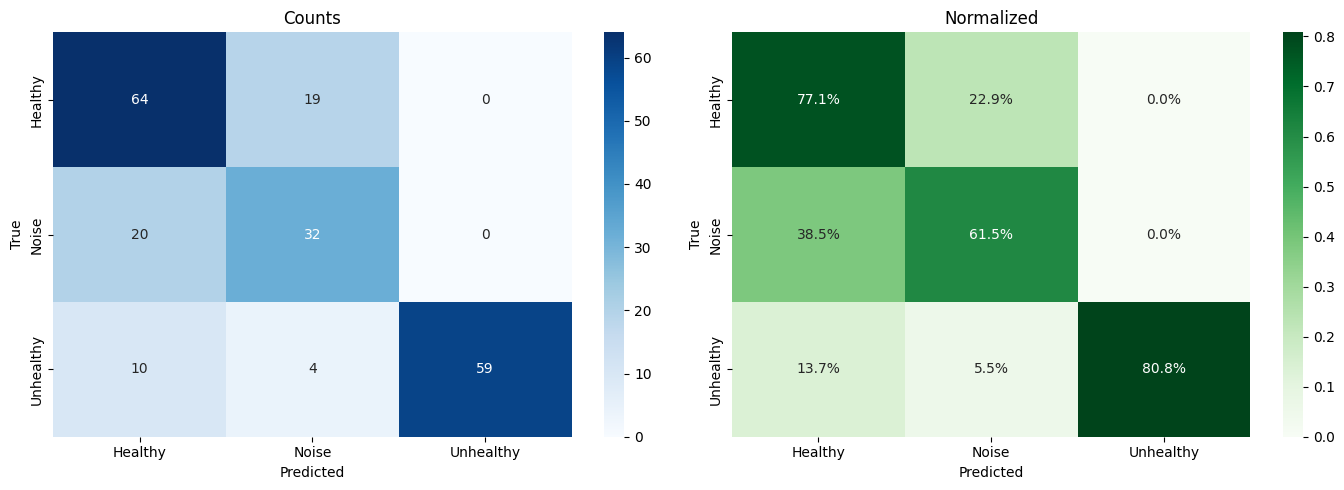

In [10]:
# ============================================================
# CELL 10: Evaluate
# ============================================================
print("=" * 70)
print("EVALUATION")
print("=" * 70)

test_results = model.evaluate(X_te, y_test_cat, verbose=0)
print(f"\nTest Accuracy:  {test_results[1]*100:.2f}%")
print(f"Test Precision: {test_results[2]*100:.2f}%")
print(f"Test Recall:    {test_results[3]*100:.2f}%")

y_pred_proba = model.predict(X_te)
y_pred = np.argmax(y_pred_proba, axis=1)
print("\n" + classification_report(y_test, y_pred, target_names=class_names, digits=4))

print("PER-CLASS ACCURACY:")
for i, name in enumerate(class_names):
    mask = y_test == i
    if np.any(mask):
        acc = np.mean(y_pred[mask] == i)
        conf = np.mean(y_pred_proba[mask, i])
        print(f"  {name:12s}: {acc*100:.1f}% (confidence: {conf:.3f})")

cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Counts'); axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
cm_n = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_n, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Normalized'); axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=200)
plt.show()

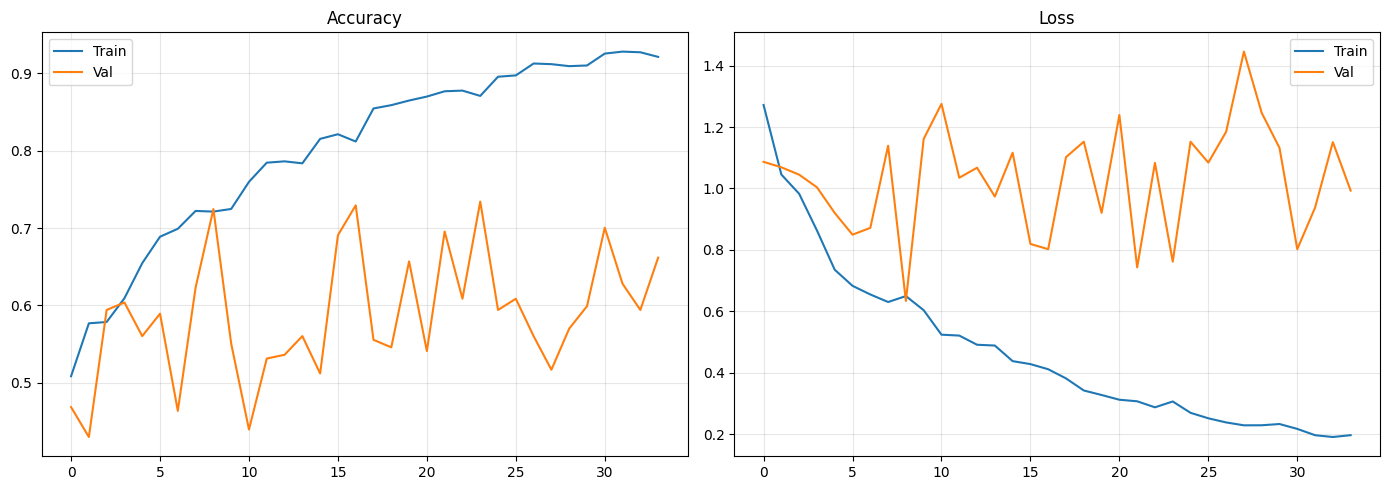

In [11]:
# ============================================================
# CELL 11: Training History
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=200)
plt.show()

ENSEMBLE TRAINING — 3 Models

--- Model 1/3 (seed=42) ---
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 8.
  Model 1 accuracy: 59.13%

--- Model 2/3 (seed=123) ---
Epoch 85: early stopping
Restoring model weights from the end of the best epoch: 65.
  Model 2 accuracy: 94.23%

--- Model 3/3 (seed=789) ---
Epoch 53: early stopping
Restoring model weights from the end of the best epoch: 33.
  Model 3 accuracy: 86.54%

🏆 Ensemble Accuracy: 92.79%
              precision    recall  f1-score   support

     Healthy     0.9383    0.9157    0.9268        83
       Noise     0.8393    0.9038    0.8704        52
   Unhealthy     0.9859    0.9589    0.9722        73

    accuracy                         0.9279       208
   macro avg     0.9212    0.9261    0.9231       208
weighted avg     0.9302    0.9279    0.9286       208

  Healthy     : 91.6%
  Noise       : 90.4%
  Unhealthy   : 95.9%


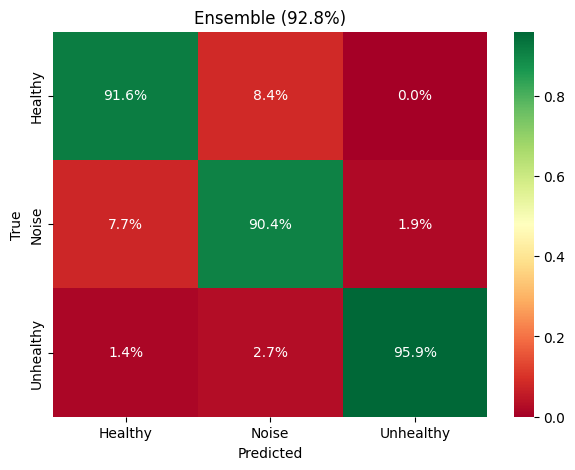

In [12]:
# ============================================================
# CELL 12: Ensemble (3 models)
# ============================================================
print("=" * 70)
print("ENSEMBLE TRAINING — 3 Models")
print("=" * 70)

ensemble_models = []
for idx, seed in enumerate([42, 123, 789]):
    print(f"\n--- Model {idx+1}/3 (seed={seed}) ---")
    tf.random.set_seed(seed)
    np.random.seed(seed)
    ens_model = build_cnn(input_shape)
    ens_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss='categorical_crossentropy', metrics=['accuracy'])
    ens_callbacks = [
        ModelCheckpoint(os.path.join(OUTPUT_DIR, f'ensemble_{idx+1}.keras'),
                        monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=0),
    ]
    ens_model.fit(X_tr, y_train_cat, validation_data=(X_vl, y_val_cat),
                  epochs=120, batch_size=16, class_weight=class_weights,
                  callbacks=ens_callbacks, verbose=0)
    res = ens_model.evaluate(X_te, y_test_cat, verbose=0)
    print(f"  Model {idx+1} accuracy: {res[1]*100:.2f}%")
    ensemble_models.append(ens_model)

# Ensemble prediction
ens_preds = np.mean([m.predict(X_te, verbose=0) for m in ensemble_models], axis=0)
y_pred_ens = np.argmax(ens_preds, axis=1)
ens_acc = np.mean(y_pred_ens == y_test)

print(f"\n{'='*70}")
print(f"🏆 Ensemble Accuracy: {ens_acc*100:.2f}%")
print(classification_report(y_test, y_pred_ens, target_names=class_names, digits=4))

for i, name in enumerate(class_names):
    mask = y_test == i
    if np.any(mask):
        print(f"  {name:12s}: {np.mean(y_pred_ens[mask]==i)*100:.1f}%")

cm_e = confusion_matrix(y_test, y_pred_ens)
plt.figure(figsize=(7, 5))
cm_en = cm_e.astype('float') / cm_e.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_en, annot=True, fmt='.1%', cmap='RdYlGn',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Ensemble ({ens_acc*100:.1f}%)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.savefig(os.path.join(OUTPUT_DIR, 'ensemble_confusion.png'), dpi=200)
plt.show()

In [13]:
# ============================================================
# CELL 13: Compare & Save
# ============================================================
single_acc = test_results[1]
best_acc = max(single_acc, ens_acc)

print("=" * 70)
print("COMPARISON")
print("=" * 70)
print(f"Single Model: {single_acc*100:.2f}%")
print(f"Ensemble:     {ens_acc*100:.2f}%")
print(f"Best:         {best_acc*100:.2f}%")

# Save
model.save(os.path.join(OUTPUT_DIR, 'poultry_cnn_model_v2.keras'))
for idx, em in enumerate(ensemble_models):
    em.save(os.path.join(OUTPUT_DIR, f'poultry_cnn_ensemble_{idx+1}.keras'))

pkg = {
    'model_type': '1D CNN V2 (ResNet + Attention)',
    'scaler': scaler,
    'class_names': class_names,
    'num_features': NUM_FEATURES,
    'test_accuracy_single': single_acc,
    'test_accuracy_ensemble': ens_acc,
    'input_shape': (NUM_FEATURES, 1),
    'num_classes': 3,
    'feature_version': 'v2_fixed',
}
with open(os.path.join(OUTPUT_DIR, 'poultry_cnn_model_package_v2.pkl'), 'wb') as f:
    pickle.dump(pkg, f)

print("\n📁 Saved files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    fp = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(fp):
        sz = os.path.getsize(fp)
        unit = 'MB' if sz > 1e6 else 'KB'
        val = sz/1e6 if sz > 1e6 else sz/1e3
        print(f"  {f} ({val:.1f} {unit})")
print("\n👉 To download: Save Version → Output tab → Download")

COMPARISON
Single Model: 74.52%
Ensemble:     92.79%
Best:         92.79%

📁 Saved files:
  __notebook__.ipynb (564.4 KB)
  best_model.keras (7.1 MB)
  confusion_matrix.png (96.7 KB)
  ensemble_1.keras (7.1 MB)
  ensemble_2.keras (7.1 MB)
  ensemble_3.keras (7.1 MB)
  ensemble_confusion.png (63.4 KB)
  poultry_cnn_ensemble_1.keras (7.1 MB)
  poultry_cnn_ensemble_2.keras (7.1 MB)
  poultry_cnn_ensemble_3.keras (7.1 MB)
  poultry_cnn_model_package_v2.pkl (6.6 KB)
  poultry_cnn_model_v2.keras (7.1 MB)
  training_history.png (183.6 KB)

👉 To download: Save Version → Output tab → Download
